In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/9971786_aggregated_results.txt')

In [3]:
df2=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/10011030_aggregated_results.txt')

In [4]:
df.columns = ['Mass', 'semi_major_axis','ejected']
df2.columns = ['Mass', 'semi_major_axis','ejected']

In [5]:
df_agg=pd.concat([df, df2], ignore_index=True)

In [6]:
df_agg

,Mass,semi_major_axis,ejected
0,0.000300,3.162278,0
1,0.000300,3.162278,0
2,0.000300,3.162278,1
3,0.000300,3.162278,1
4,0.000300,3.162278,1
...,...,...,...
4491,0.009495,39.810717,0
4492,0.009495,39.810717,0
4493,0.009495,39.810717,0
4494,0.009495,39.810717,0


In [4]:
df

,Mass,semi_major_axis,ejected
0,0.000300,3.162278,0
1,0.000300,3.162278,0
2,0.000300,3.162278,1
3,0.000300,3.162278,1
4,0.000300,3.162278,1
...,...,...,...
2492,0.001689,11.220185,1
2493,0.001689,11.220185,0
2494,0.001689,11.220185,1
2495,0.001689,11.220185,1


In [17]:
ejected_df=df_agg[df_agg.ejected == 0]

In [18]:
total_df=df_agg.groupby(['Mass', 'semi_major_axis']).size().reset_index(name='count')

In [19]:
total_df

,Mass,semi_major_axis,count
0,0.000300,3.162278,498
1,0.000300,11.220185,500
2,0.000300,39.810717,500
3,0.001689,3.162278,500
4,0.001689,11.220185,499
5,0.001689,39.810717,500
6,0.009495,3.162278,500
7,0.009495,11.220185,499
8,0.009495,39.810717,500


In [20]:
heatmap_df=ejected_df.groupby(['Mass', 'semi_major_axis']).size().reset_index(name='count')

In [21]:
heatmap_df['ejection_fraction'] = heatmap_df['count'] / total_df['count']

In [22]:
heatmap_df

,Mass,semi_major_axis,count,ejection_fraction
0,0.000300,3.162278,204,0.409639
1,0.000300,11.220185,13,0.026000
2,0.000300,39.810717,3,0.006000
3,0.001689,3.162278,287,0.574000
4,0.001689,11.220185,284,0.569138
5,0.001689,39.810717,219,0.438000
6,0.009495,3.162278,308,0.616000
7,0.009495,11.220185,288,0.577154
8,0.009495,39.810717,304,0.608000


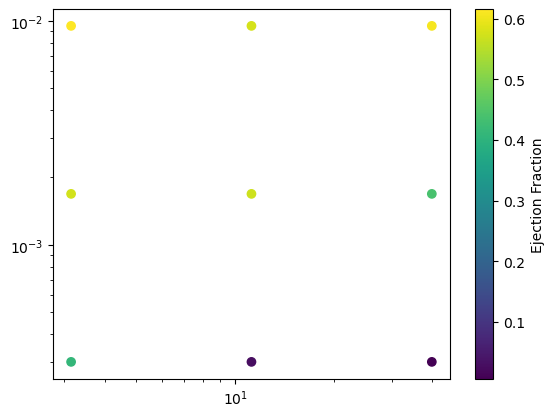

In [23]:
plt.scatter(heatmap_df['semi_major_axis'], heatmap_df['Mass'], c=heatmap_df['ejection_fraction'], cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Ejection Fraction')

In [7]:
import rebound

In [23]:
sim = rebound.Simulation()
sim.add(m=1.)
sim.add(m=0, x=9)
sim.boundary = 'open'
sim.configure_box(1000.0)
print(len(sim.particles))
sim.integrate(1)


2


In [24]:
len(sim.particles)

2

In [12]:
sim.integrate(10)

NoParticles: No more particles left in simulation.

0.0